#### News Topic Classifier Using BERT

**Objective:** Fine-tune `bert-base-uncased` on the AG News dataset to classify news headlines into 4 topic categories: World, Sports, Business, and Science/Technology.

**Dataset:** AG News 

In [16]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hugging Face
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# PyTorch
import torch
from torch.utils.data import Dataset

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version : 2.11.0+cpu
Device          : CPU


#### Configuration

In [17]:
TRAIN_SIZE   = 3000
VAL_SIZE     = 500
MAX_LEN      = 64     
BATCH_SIZE   = 16
EPOCHS       = 3
LEARNING_RATE = 2e-5   # Standard learning rate
MODEL_NAME   = 'bert-base-uncased'
OUTPUT_DIR   = './bert_news_model'
SEED         = 42

# AG News label mapping - these are the 4 categories
LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

torch.manual_seed(SEED)

#### 1. Load Dataset

In [18]:
raw = load_dataset('ag_news')

print("Dataset splits:", raw)
print("\nSample record:")
print(raw['train'][0])

Dataset splits: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Sample record:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [19]:
# Taking a stratified subset so all 4 classes are equally represented in training
# shuffle first so we don't just grab the first N rows of one class
train_full = raw['train'].shuffle(seed=SEED)
test_full  = raw['test'].shuffle(seed=SEED)

train_data = train_full.select(range(TRAIN_SIZE))
val_data   = test_full.select(range(VAL_SIZE))
test_data  = test_full.select(range(VAL_SIZE, VAL_SIZE + 500))  # held-out test set

print(f"Train samples : {len(train_data)}")
print(f"Val samples   : {len(val_data)}")
print(f"Test samples  : {len(test_data)}")

Train samples : 3000
Val samples   : 500
Test samples  : 500


#### 2. Exploratory Data Analysis

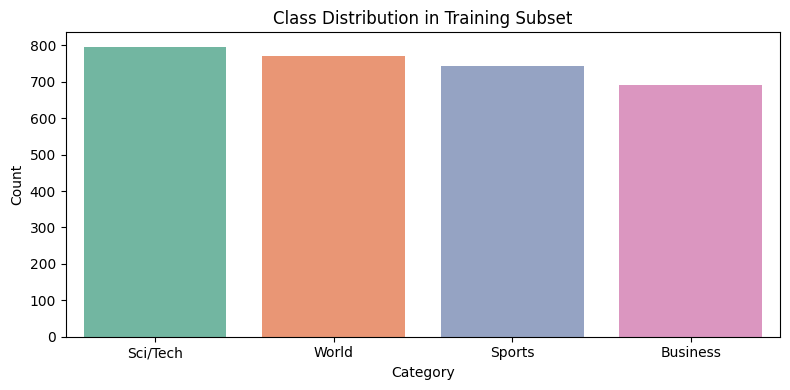

label_name
Sci/Tech    796
World       771
Sports      742
Business    691
Name: count, dtype: int64


In [20]:
# Checking class distribution in our training subset
train_df = pd.DataFrame(train_data)
train_df['label_name'] = train_df['label'].map(dict(enumerate(LABEL_NAMES)))

counts = train_df['label_name'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, palette='Set2')
plt.title('Class Distribution in Training Subset')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(counts)

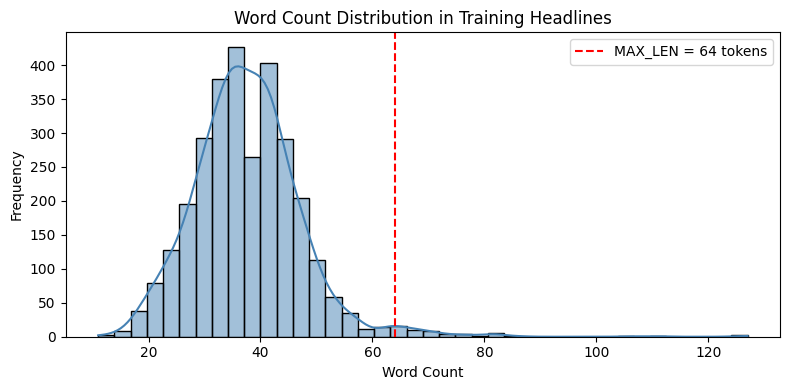

Mean words  : 37.7
Max words   : 127
95th pct    : 53


In [21]:
# Checking text length distribution to confirm MAX_LEN=64 is a reasonable choice
# If most texts are under 64 tokens, we're not cutting off much useful information
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(train_df['word_count'], bins=40, kde=True, color='steelblue')
plt.axvline(x=64, color='red', linestyle='--', label='MAX_LEN = 64 tokens')
plt.title('Word Count Distribution in Training Headlines')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean words  : {train_df['word_count'].mean():.1f}")
print(f"Max words   : {train_df['word_count'].max()}")
print(f"95th pct    : {train_df['word_count'].quantile(0.95):.0f}")

In [22]:
# A few sample headlines per category
for label_id, label_name in enumerate(LABEL_NAMES):
    samples = train_df[train_df['label'] == label_id]['text'].head(2).tolist()
    print(f"\n[{label_name}]")
    for s in samples:
        print(f"  • {s[:120]}")


[World]
  • Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day
  • Will Putin #39;s Power Play Make Russia Safer? Outwardly, Russia has not changed since the barrage of terrorist attacks 

[Sports]
  • Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a 
  • Mutombo says he #39;s being traded to Rockets; will back up, mentor &lt;b&gt;...&lt;/b&gt; Dikembe Mutombo, 38, has agre

[Business]
  • Economy builds steam in KC Fed district The economy continued to strengthen in September and early October in the Great 
  • RBC Centura CEO steps down RALEIGH, NC - The head of RBC Centura Bank has stepped down, and his successor will run the b

[Sci/Tech]
  • U2 pitches for Apple New iTunes ads airing during baseball games Tuesday will feature the advertising-shy Irish rockers.
  • A Cosmic Storm: When Galaxy Clusters Collide Astronomers have found what they 

#### 3. Tokenization

In [23]:
# Loading the BERT tokenizer 
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print(f"Vocab size: {tokenizer.vocab_size:,}")

# Quick sanity check on what tokenization looks like
sample = "Stock markets rally as Fed holds interest rates steady"
tokens = tokenizer.tokenize(sample)
print(f"\nSample text   : {sample}")
print(f"Tokenized     : {tokens}")
print(f"Token count   : {len(tokens)}")

Vocab size: 30,522

Sample text   : Stock markets rally as Fed holds interest rates steady
Tokenized     : ['stock', 'markets', 'rally', 'as', 'fed', 'holds', 'interest', 'rates', 'steady']
Token count   : 9


In [24]:
# Custom PyTorch Dataset class 
# Each item returns input_ids, attention_mask, and the label as a tensor

class NewsDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len):
        self.data      = hf_dataset
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        encoding = self.tokenizer(
            item['text'],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(item['label'], dtype=torch.long)
        }


train_dataset = NewsDataset(train_data, tokenizer, MAX_LEN)
val_dataset   = NewsDataset(val_data,   tokenizer, MAX_LEN)
test_dataset  = NewsDataset(test_data,  tokenizer, MAX_LEN)

print(f"Train dataset : {len(train_dataset)} samples")
print(f"Val dataset   : {len(val_dataset)} samples")
print(f"Test dataset  : {len(test_dataset)} samples")

Train dataset : 3000 samples
Val dataset   : 500 samples
Test dataset  : 500 samples


#### 4. Model Setup & Training

In [25]:
# Loading BERT with a classification head on top
# num_labels=4 adds a linear layer that maps BERT's output to 4 class scores
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1981.41it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Total parameters     : 109,485,316
Trainable parameters : 109,485,316


In [26]:
# The function is called by the Trainer after each evaluation step
# Returns both accuracy and macro F1 so we can track both during training
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        'accuracy' : accuracy_score(labels, predictions),
        'f1'       : f1_score(labels, predictions, average='macro')
    }

In [27]:
# %pip install "accelerate>=1.1.0"

In [28]:
# Training configuration 
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = 0.01,       # mild regularization to prevent overfitting
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    save_total_limit            = 1,
    logging_dir                 = './logs',
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = 'none'     
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [29]:
# The Trainer handles the training loop, gradient updates, evaluation, and checkpointing
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics
)

In [ ]:
print("Starting training...")
train_result = trainer.train()

print(f"\nTraining complete.")
print(f"Total training time : {train_result.metrics['train_runtime']:.0f}s")
print(f"Samples per second  : {train_result.metrics['train_samples_per_second']:.2f}")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.157652,0.424851,0.886000,0.886746
2,0.128748,0.419823,0.894000,0.895209
3,0.037929,0.447448,0.892000,0.892986


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.53s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


Training complete.
Total training time : 4308s
Samples per second  : 2.09


#### 5. Evaluation

In [ ]:
preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

test_accuracy = accuracy_score(y_true, y_pred)
test_f1       = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy   : {test_accuracy:.4f}")
print(f"Test F1 (macro) : {test_f1:.4f}")

Test Accuracy   : 0.9020
Test F1 (macro) : 0.8992


#### 5. Evaluation

In [ ]:
print("CLASSIFICATION REPORT")
print('='*55)
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World       0.94      0.89      0.91       146
      Sports       0.96      0.99      0.98       125
    Business       0.86      0.82      0.84       112
    Sci/Tech       0.84      0.90      0.87       117

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



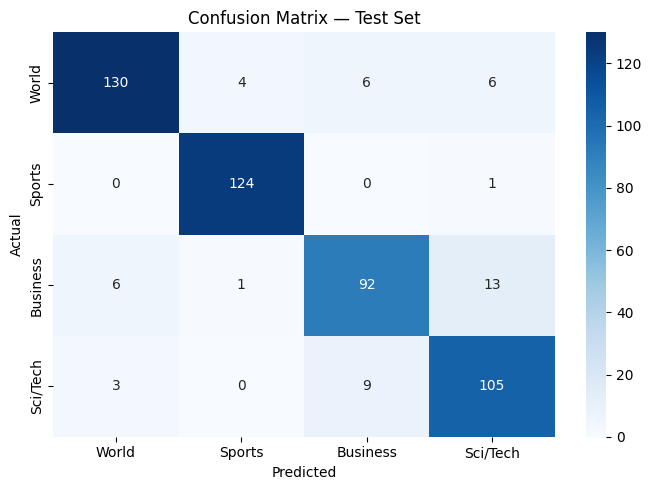

In [35]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

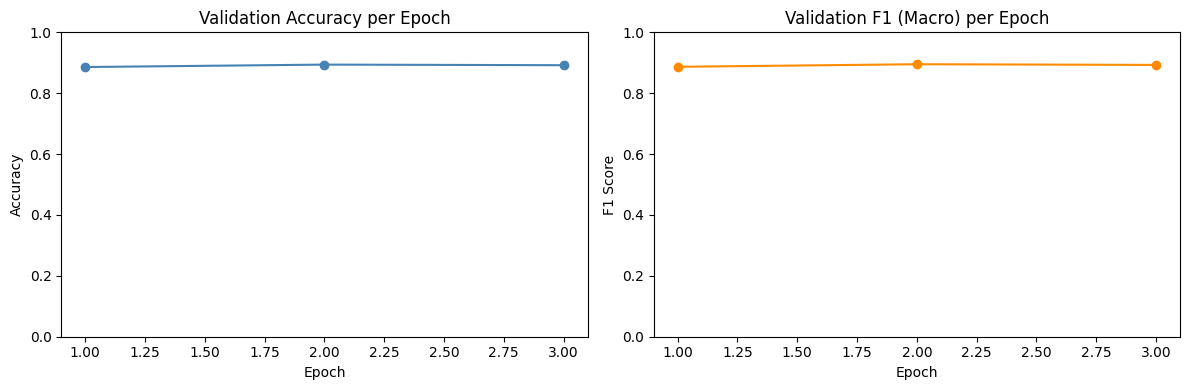

In [36]:
# Plotting how accuracy and F1 changed across epochs
log_history = trainer.state.log_history

eval_logs = [x for x in log_history if 'eval_accuracy' in x]

if eval_logs:
    epochs_list = [x['epoch'] for x in eval_logs]
    acc_list    = [x['eval_accuracy'] for x in eval_logs]
    f1_list     = [x['eval_f1'] for x in eval_logs]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_list, acc_list, marker='o', color='steelblue')
    axes[0].set_title('Validation Accuracy per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)

    axes[1].plot(epochs_list, f1_list, marker='o', color='darkorange')
    axes[1].set_title('Validation F1 (Macro) per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

#### 6. Save Model

In [ ]:
# Saving the fine-tuned model and tokenizer to disk
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Model and tokenizer saved to: {OUTPUT_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:16<00:00, 16.54s/it]


Model and tokenizer saved to: ./bert_news_model


#### Summary

- Fine-tuned `bert-base-uncased` on AG News
- Most confusions occur between **Business ↔ Sci/Tech** (overlapping vocabulary)